In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
data = fetch_california_housing()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (16512, 8)
Testing Data Shape: (4128, 8)


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling Complete")

Scaling Complete


In [ ]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results:")
print("RMSE:", rmse_lr)
print("R2 Score:", r2_lr)

Linear Regression Results:
RMSE: 0.7455813830127763
R2 Score: 0.575787706032451


In [ ]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_scaled)

rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge Regression Results:")
print("RMSE:", rmse_ridge)
print("R2 Score:", r2_ridge)

Ridge Regression Results:
RMSE: 0.7455567442814779
R2 Score: 0.5758157428913684


In [ ]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Results:")
print("RMSE:", rmse_dt)
print("R2 Score:", r2_dt)

Decision Tree Results:
RMSE: 0.7037294974840077
R2 Score: 0.622075845135081


In [ ]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression", "Decision Tree"],
    "RMSE": [rmse_lr, rmse_ridge, rmse_dt],
    "R2 Score": [r2_lr, r2_ridge, r2_dt]
})

comparison

,Model,RMSE,R2 Score
0,Linear Regression,0.745581,0.575788
1,Ridge Regression,0.745557,0.575816
2,Decision Tree,0.703729,0.622076


In [ ]:
best_model = comparison.sort_values(by="R2 Score", ascending=False)

print("Best Performing Model:")
print(best_model.iloc[0])

Best Performing Model:
Model       Decision Tree
RMSE             0.703729
R2 Score         0.622076
Name: 2, dtype: object


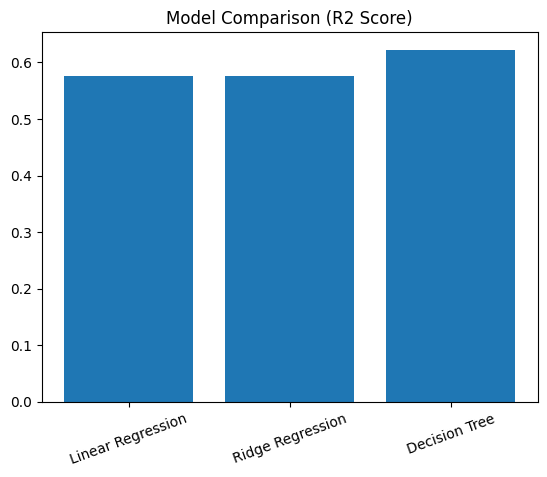

In [ ]:
plt.bar(comparison["Model"], comparison["R2 Score"])
plt.title("Model Comparison (R2 Score)")
plt.xticks(rotation=20)
plt.show()

# 🔎 Conclusion

In Task 2, three regression models were implemented and compared:  
Linear Regression, Ridge Regression, and Decision Tree Regressor.

Feature scaling was applied to improve model performance and ensure fair comparison between algorithms.

The models were evaluated using RMSE and R² Score.

Among the three models, the **Decision Tree Regressor** achieved the highest R² score of **0.622076** and the lowest RMSE of **0.703729**, indicating better predictive accuracy.

## 🏆 Final Result:
**Decision Tree is the best performing model for this dataset.**